<a href="https://colab.research.google.com/github/shanikagalaudage/includeher_paper/blob/main/PlotsTables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Notes

Shared **data** helpers and **overlapping figures** (subject breakdown, grouped region bar) call `Plot_Figures_UK.py` directly so layout and colours match the script (TEAL subject bars, purple region bar).

Pie charts and combined region donuts are notebook-only and keep their original styling.


In [1]:
%matplotlib inline
import os
import sys
sys.path.insert(0, os.path.abspath("."))
import Plot_Figures_UK as pf
import matplotlib.pyplot as plt
# Importing pf applies the same rcParams as Plot_Figures_UK.py
colours = pf.COLOURS  # used only for notebook-only pie charts


# Key Stage 5 — A-Level / Scottish Highers


In [2]:
ks5 = pf.prepare_key_stage("ks5")



=== UNIQUE SCIENTISTS (GLOBAL, DEDUPLICATED ACROSS ALL EXAM BOARDS) ===
Total unique scientists (distinct named individuals): 171
Unique scientists by gender: {'male': 168, 'female': 3}
Unique scientists by region: {'europe': 129, 'north america': 35, 'oceania': 1, 'europe-north america': 4, 'asia-north america': 1, 'oceania-europe': 1}

=== TOTAL SCIENTIST-CATEGORY MENTIONS PER EXAM BOARD ===
AQA: 0 scientist-category mentions
CCEA: 0 scientist-category mentions
Edexcel: 0 scientist-category mentions
OCR: 16 scientist-category mentions
Scottish_highers: 11 scientist-category mentions
WJEC: 4 scientist-category mentions

=== TOTAL CONCEPT-CATEGORY MENTIONS PER EXAM BOARD ===
AQA: 99 concept-category mentions
CCEA: 50 concept-category mentions
Edexcel: 57 concept-category mentions
OCR: 84 concept-category mentions
Scottish_highers: 87 concept-category mentions
WJEC: 81 concept-category mentions

=== TOTAL SCIENTIST-CATEGORY MENTIONS PER EXAM BOARD AND SUBJECT ===

AQA:
  physics: 0 sci

### Optional: PDF surname search


In [3]:
'''
EXTRA_SURNAMES = ["Curie", "Lovelace", "Meitner", "Solomon", "Cannon", "Rubin", "Burnell",
                  "Hodgkin", "McClintock", "Carson", "Goodall", "Herschel", "Leakey", "Wu",
                  "Anning", "Cori", "Punnett", "Dalton", "Mendeleev", "Lewis",
                 "Lussac", "Lavoisier", "Volta", "Joule",
                 "Chadwick", "Linnaeus", "Leeuwenhoek", "Jenner", "Pasteur",
                 "Wegener", "Richter"]
last_names_only = [n.split()[-1] for n in ks5["scientists"]] + EXTRA_SURNAMES
KS4_OCR_SPECS = [
    #"/Users/gregcooke/IncludeHerUK/Specifications/KS4/gcse-chemistry-spec.pdf",
   # "/Users/gregcooke/IncludeHerUK/Specifications/KS4/gcse-biology-spec.pdf",
   # "/Users/gregcooke/IncludeHerUK/Specifications/KS4/gcse-physics-spec.pdf" 
]
pf.report_pdf_search(pf.search_names_in_pdfs(last_names_only, KS4_OCR_SPECS))
'''

'\nEXTRA_SURNAMES = ["Curie", "Lovelace", "Meitner", "Solomon", "Cannon", "Rubin", "Burnell",\n                  "Hodgkin", "McClintock", "Carson", "Goodall", "Herschel", "Leakey", "Wu",\n                  "Anning", "Cori", "Punnett", "Dalton", "Mendeleev", "Lewis",\n                 "Lussac", "Lavoisier", "Volta", "Joule",\n                 "Chadwick", "Linnaeus", "Leeuwenhoek", "Jenner", "Pasteur",\n                 "Wegener", "Richter"]\nlast_names_only = [n.split()[-1] for n in ks5["scientists"]] + EXTRA_SURNAMES\nKS4_OCR_SPECS = [\n    #"/Users/gregcooke/IncludeHerUK/Specifications/KS4/gcse-chemistry-spec.pdf",\n   # "/Users/gregcooke/IncludeHerUK/Specifications/KS4/gcse-biology-spec.pdf",\n   # "/Users/gregcooke/IncludeHerUK/Specifications/KS4/gcse-physics-spec.pdf" \n]\npf.report_pdf_search(pf.search_names_in_pdfs(last_names_only, KS4_OCR_SPECS))\n'

### KS5 figures shared with `Plot_Figures_UK.py` (TEAL subject breakdown)


Saved: /Users/gregcooke/IncludeHerUK/Figures/summary_subjects_A_Level_UK.png


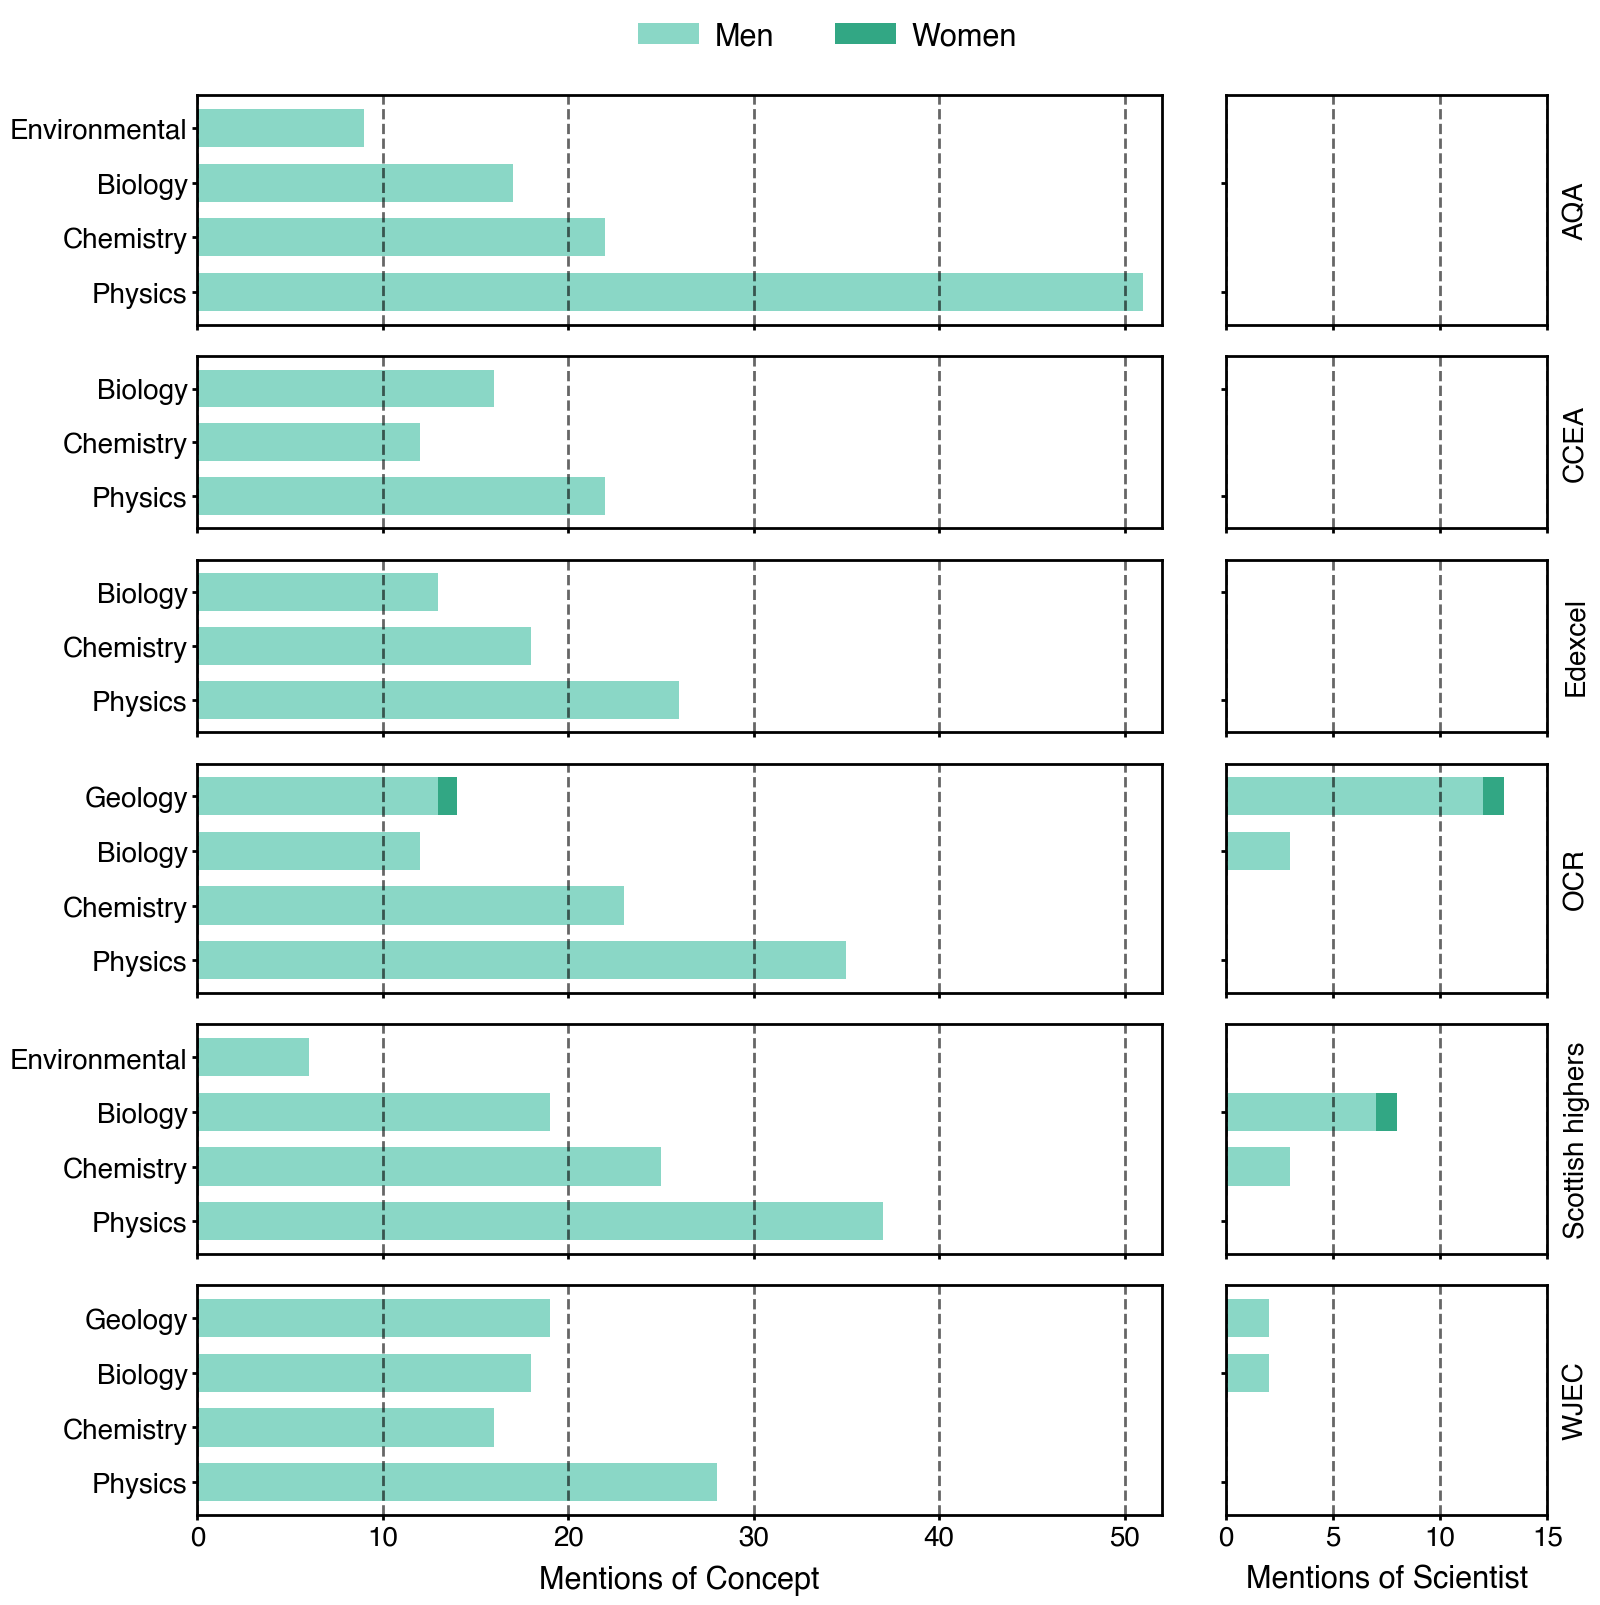

In [4]:
BOARDS_A = pf.KEY_STAGES["ks5"]["boards_map"]
pf.plot_subject_breakdown(
    list(BOARDS_A), BOARDS_A, ks5["dataset"],
    os.path.join(pf.BASE_DIR, "Figures/summary_subjects_A_Level_UK.png"),
    "A_Level",
)


### KS5 figures — notebook only (pies & region donut)


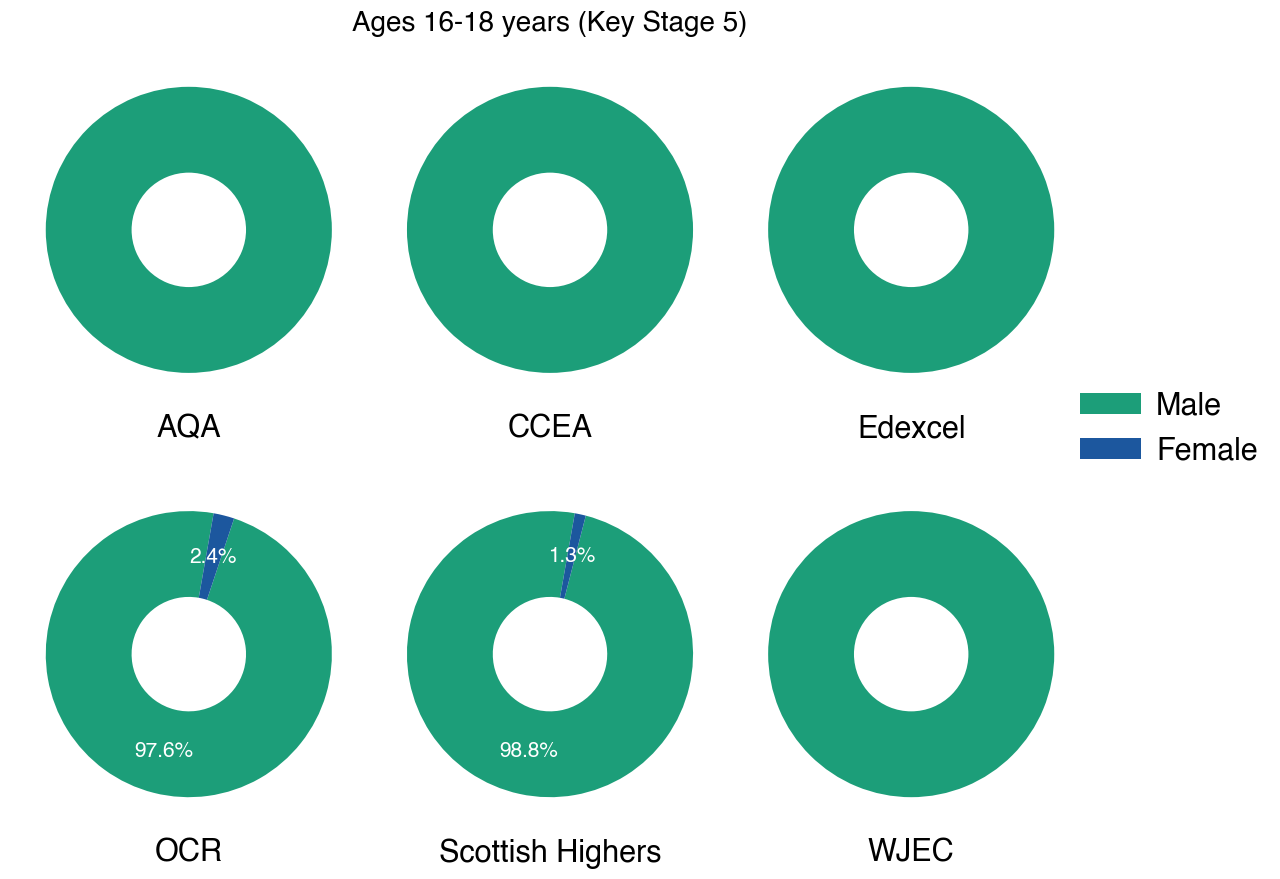

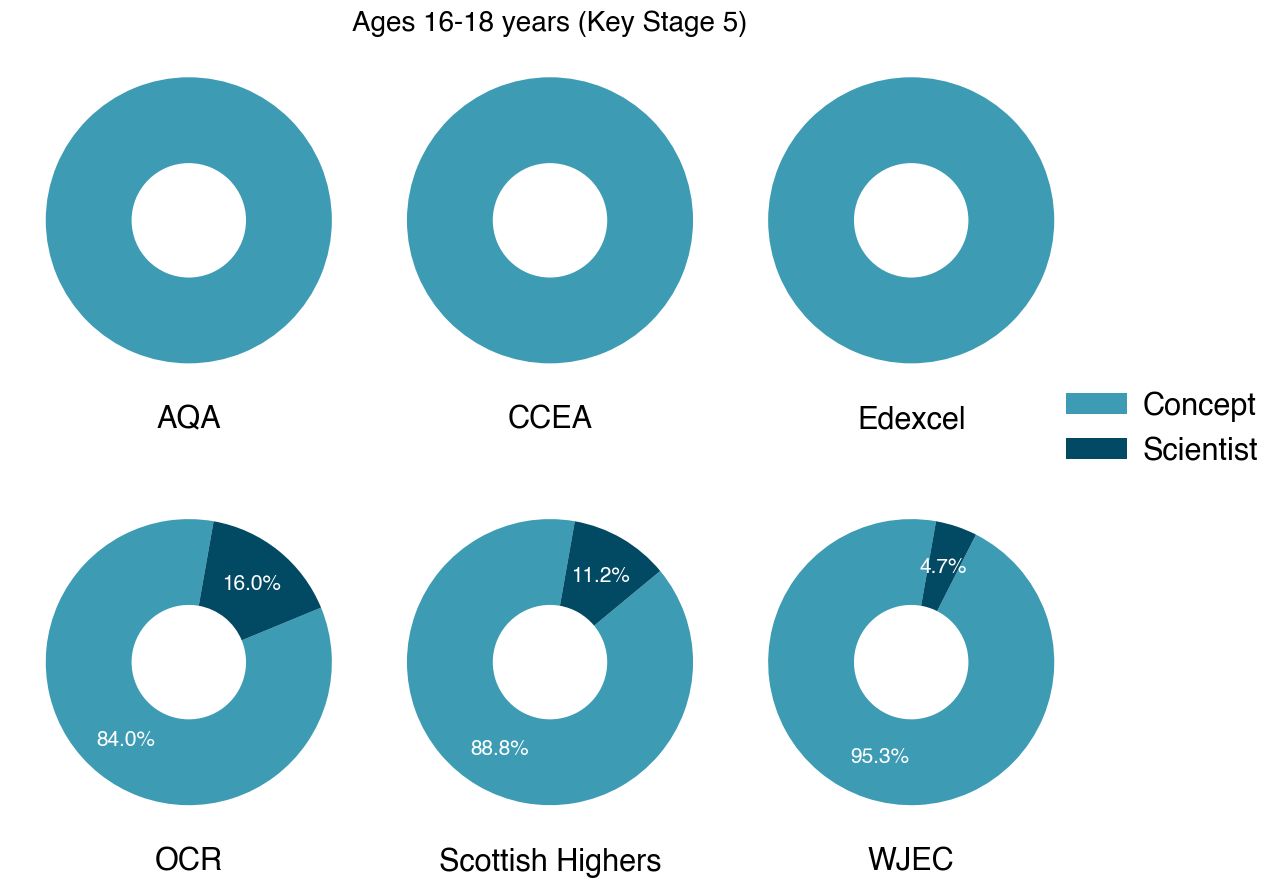

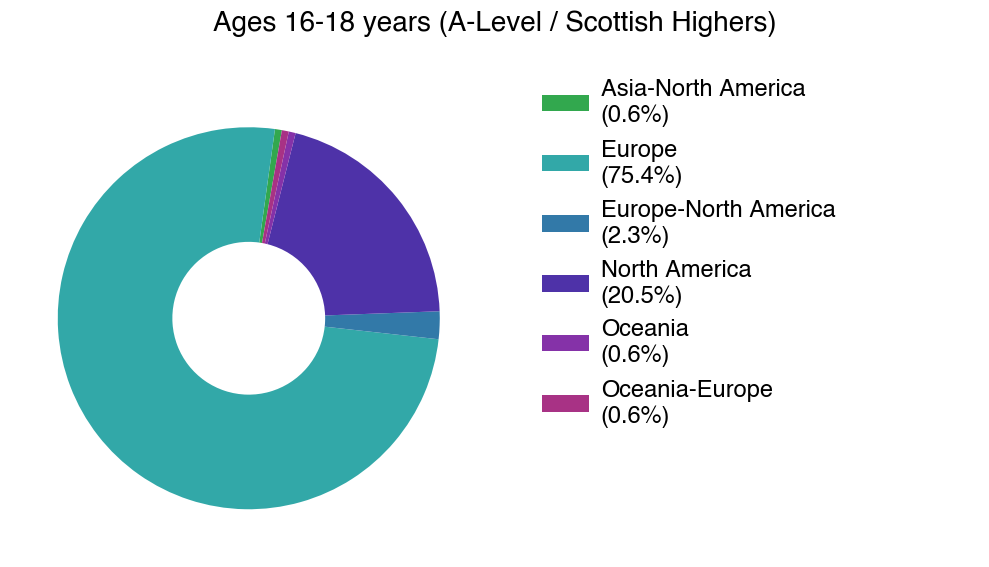

In [5]:
exam_boards = ks5["exam_boards"]
EXAMBOARDS = ks5["EXAMBOARDS"]
dataset = ks5["dataset"]
regions, vals, labels = ks5["regions"], ks5["vals"], ks5["labels"]
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 9))
ax = ax.flatten()
for jj in range(6):
    m = dataset[EXAMBOARDS[exam_boards[jj]]]["overall"]["unique"]["male"]
    f = dataset[EXAMBOARDS[exam_boards[jj]]]["overall"]["unique"]["female"]
    val = [m, f]
    if f == 0:
        ax[jj].pie(val, colors=[colours[1], colours[0]], startangle=80, wedgeprops=dict(width=.6))
    else:
        ax[jj].pie(val, colors=[colours[1], colours[0]], startangle=80, wedgeprops=dict(width=.6),
                   autopct='%1.1f%%', pctdistance=0.7, textprops={'fontsize': 15, 'color': 'white'})
    label = 'Scottish Highers' if exam_boards[jj] == 'Scottish highers' else exam_boards[jj]
    ax[jj].set_xlabel(label)
for kk in range(len(ax)):
    if kk >= len(exam_boards):
        ax[kk].axis('off')
plt.figlegend(['Male', 'Female'], bbox_to_anchor=(1.1, 0.57), bbox_transform=fig.transFigure,
              ncol=1, borderaxespad=0., handletextpad=0.5, columnspacing=1)
plt.subplots_adjust(wspace=0.01, hspace=0.1, left=0.05, right=0.95, top=0.95, bottom=0.05)
plt.suptitle('Ages 16-18 years (Key Stage 5)', fontsize=20, weight='bold')
plt.savefig(os.path.join(pf.BASE_DIR, 'Figures/summary_male_vs_female_UK_A_Level.png'), dpi=100, bbox_inches='tight')

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 9))
ax = ax.flatten()
for jj in range(6):
    board_key = EXAMBOARDS[exam_boards[jj]]
    m1 = dataset[board_key]["overall"]["concept"]["male"]
    f1 = dataset[board_key]["overall"]["concept"]["female"]
    m2 = dataset[board_key]["overall"]["scientist"]["male"]
    f2 = dataset[board_key]["overall"]["scientist"]["female"]
    val = [m1 + f1, m2 + f2]
    if m2 + f2 == 0:
        ax[jj].pie(val, colors=[colours[3], colours[2]], startangle=80, wedgeprops=dict(width=.6))
    else:
        ax[jj].pie(val, colors=[colours[3], colours[2]], startangle=80, wedgeprops=dict(width=.6),
                   autopct='%1.1f%%', pctdistance=0.7, textprops={'fontsize': 15, 'color': 'white'})
    label = 'Scottish Highers' if exam_boards[jj] == 'Scottish highers' else exam_boards[jj]
    ax[jj].set_xlabel(label)
for kk in range(len(ax)):
    if kk >= len(exam_boards):
        ax[kk].axis('off')
plt.figlegend(['Concept', 'Scientist'], bbox_to_anchor=(1.1, 0.57), bbox_transform=fig.transFigure,
              ncol=1, borderaxespad=0., handletextpad=0.5, columnspacing=1)
plt.subplots_adjust(wspace=0.01, hspace=0.2, left=0.05, right=0.95, top=0.95, bottom=0.05)
plt.suptitle('Ages 16-18 years (Key Stage 5)', fontsize=20)
plt.savefig(os.path.join(pf.BASE_DIR, 'Figures/summary_concept_vs_scientist_UK_A_Level.png'), dpi=100, bbox_inches='tight')

Colours = ["#32a84e", "#32a8a8", "#3279a8", "#4e32a8", "#8532a8", "#a83285"]
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
ax[0].pie(vals, colors=Colours, startangle=80, wedgeprops=dict(width=.6), textprops={'fontsize': 18, 'color': 'black'})
ax[1].pie(vals, colors=['white'] * len(vals))
plt.figlegend(labels, bbox_to_anchor=(0.85, 0.88), bbox_transform=fig.transFigure,
              ncol=1, borderaxespad=0., handletextpad=0.5, columnspacing=1, fontsize=17)
plt.suptitle('Ages 16-18 years (A-Level / Scottish Highers)', fontsize=20, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(pf.BASE_DIR, 'Figures/summary_region_all_UK_A_Level.png'), dpi=100, bbox_inches='tight')



# Key Stage 4 — GCSE / NQ5


In [6]:
ks4 = pf.prepare_key_stage("ks4")



=== UNIQUE SCIENTISTS (GLOBAL, DEDUPLICATED ACROSS ALL EXAM BOARDS) ===
Total unique scientists (distinct named individuals): 89
Unique scientists by gender: {'male': 86, 'nan': 1, 'female': 2}
Unique scientists by region: {'europe': 66, 'north america': 14, 'nan': 1, 'oceania': 2, 'africa': 2, 'asia-north america': 1, 'asia': 1, 'europe-oceania': 1, 'oceania-europe': 1}

=== TOTAL SCIENTIST-CATEGORY MENTIONS PER EXAM BOARD ===
AQA: 12 scientist-category mentions
CCEA: 5 scientist-category mentions
Edexcel: 20 scientist-category mentions
OCR_A: 11 scientist-category mentions
OCR_B: 23 scientist-category mentions
Scottish: 1 scientist-category mentions
WJEC: 16 scientist-category mentions

=== TOTAL CONCEPT-CATEGORY MENTIONS PER EXAM BOARD ===
AQA: 18 concept-category mentions
CCEA: 25 concept-category mentions
Edexcel: 46 concept-category mentions
OCR_A: 23 concept-category mentions
OCR_B: 12 concept-category mentions
Scottish: 13 concept-category mentions
WJEC: 11 concept-category me

### KS4 figures shared with `Plot_Figures_UK.py` (TEAL subject breakdown)


Saved: /Users/gregcooke/IncludeHerUK/Figures/summary_subjects_GCSE_UK.png


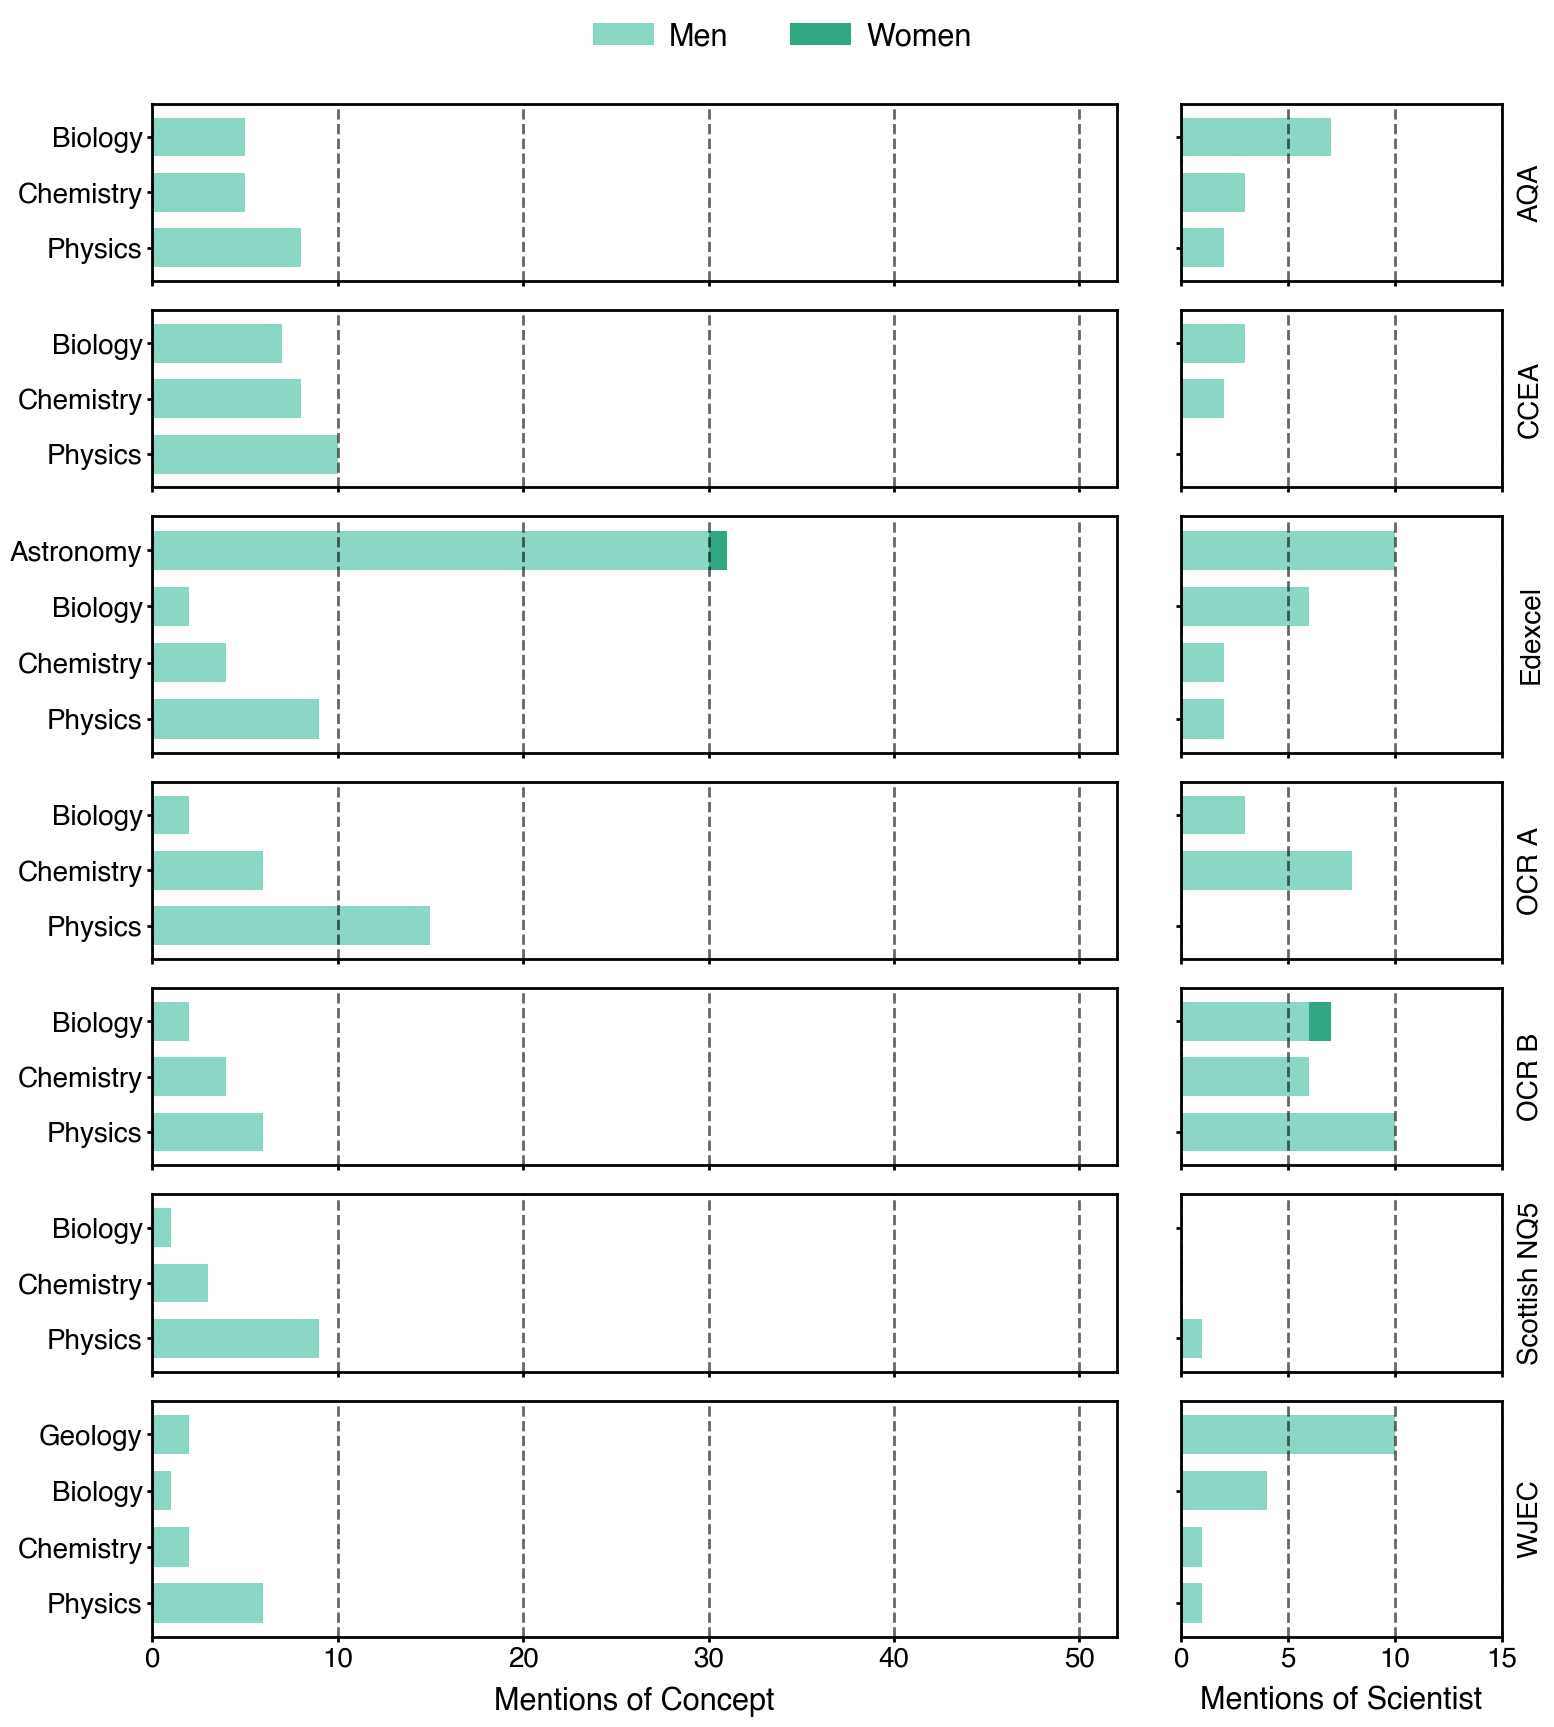

In [7]:
BOARDS_G = pf.KEY_STAGES["ks4"]["boards_map"]
pf.plot_subject_breakdown(
    list(BOARDS_G), BOARDS_G, ks4["dataset"],
    os.path.join(pf.BASE_DIR, "Figures/summary_subjects_GCSE_UK.png"),
    "GCSE",
)


### KS4 figures — notebook only


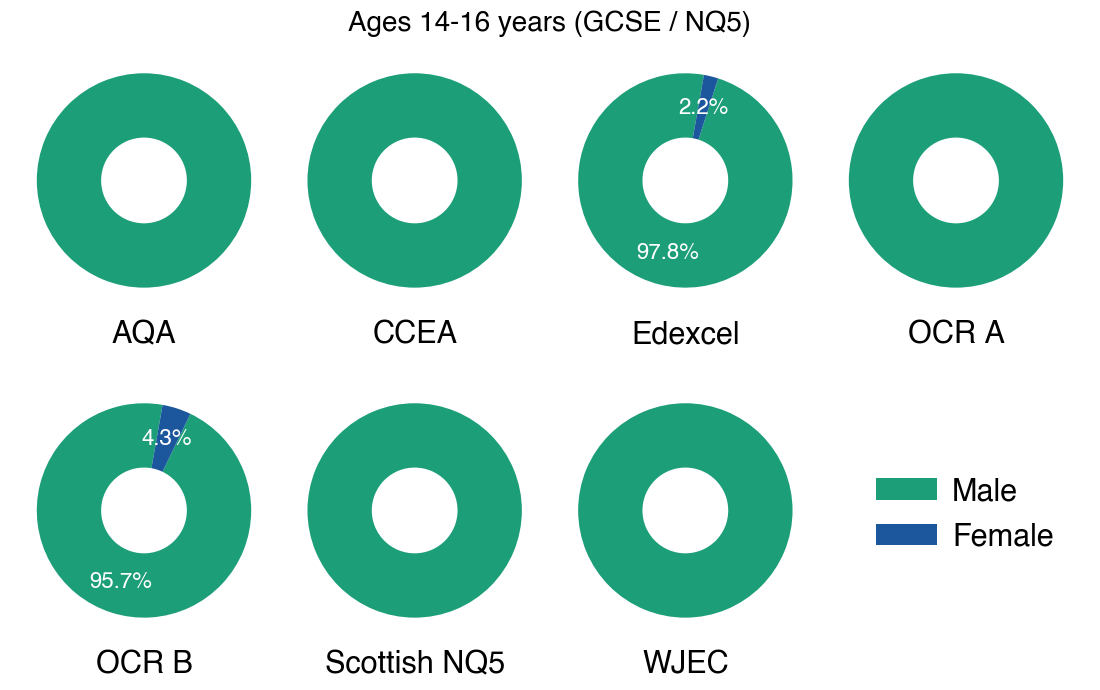

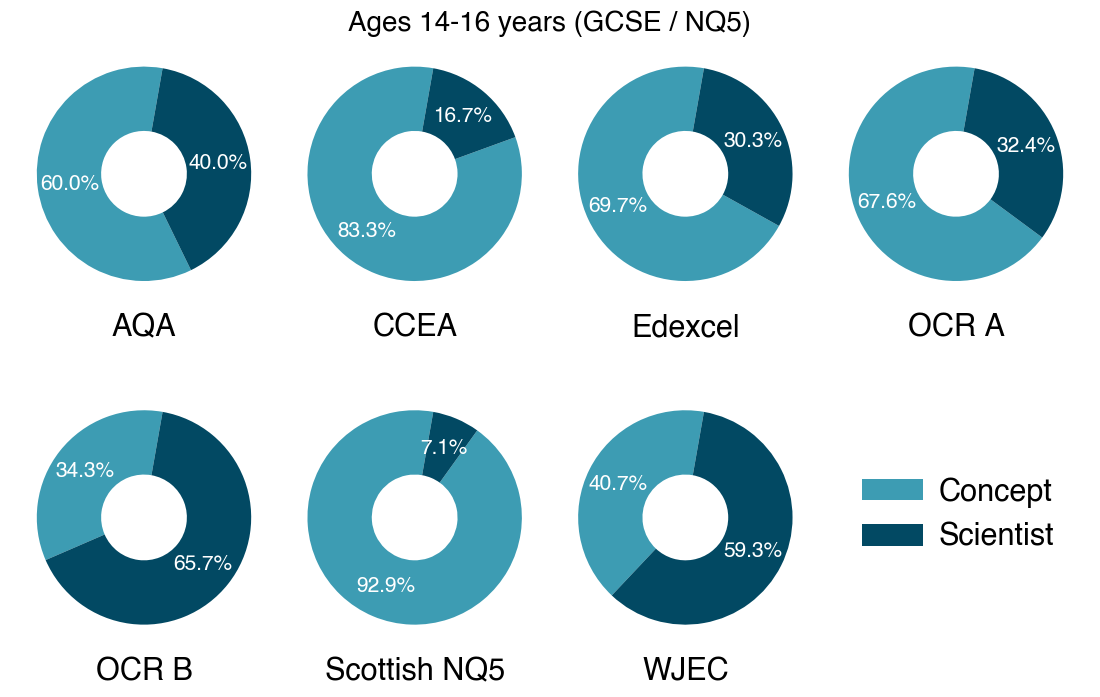

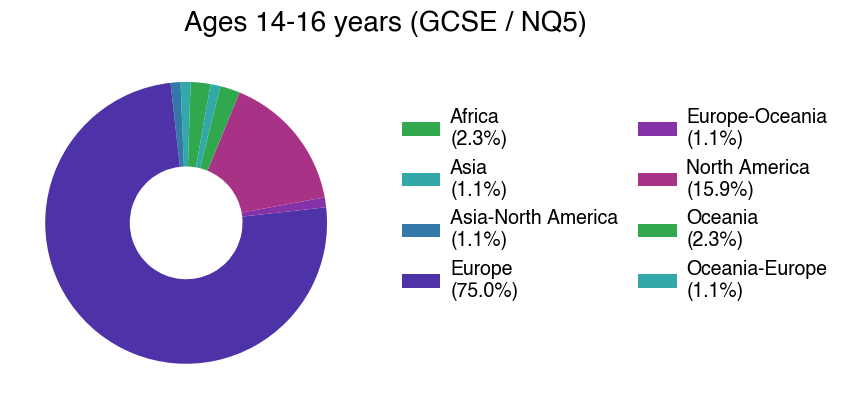

In [8]:
exam_boards = ks4["exam_boards"]
EXAMBOARDS = ks4["EXAMBOARDS"]
dataset = ks4["dataset"]
regions, vals, labels = ks4["regions"], ks4["vals"], ks4["labels"]
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(12, 7))
ax = ax.flatten()
for jj, board in enumerate(exam_boards):
    board_key = EXAMBOARDS[board]
    m = dataset[board_key]["overall"]["unique"]["male"]
    f = dataset[board_key]["overall"]["unique"]["female"]
    val = [m, f]
    if f == 0:
        ax[jj].pie(val, colors=[colours[1], colours[0]], startangle=80, wedgeprops=dict(width=.6))
    else:
        ax[jj].pie(val, colors=[colours[1], colours[0]], startangle=80, wedgeprops=dict(width=.6),
                   autopct='%1.1f%%', pctdistance=0.7, textprops={'fontsize': 16, 'color': 'white'})
    label = 'Scottish NQ5' if board == 'Scottish NQ5' else board
    ax[jj].set_xlabel(label)
for kk in range(len(exam_boards), len(ax)):
    ax[kk].axis('off')
plt.figlegend(['Male', 'Female'], bbox_to_anchor=(0.93, 0.33), bbox_transform=fig.transFigure,
              ncol=1, borderaxespad=0., handletextpad=0.5, columnspacing=1)
plt.subplots_adjust(wspace=0.01, hspace=0.1, left=0.05, right=0.95, top=0.95, bottom=0.05)
plt.suptitle('Ages 14-16 years (GCSE / NQ5)', fontsize=20)
plt.savefig(os.path.join(pf.BASE_DIR, 'Figures/summary_male_vs_female_UK_GCSE.png'), dpi=100, bbox_inches='tight')

fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(12, 7))
ax = ax.flatten()
for jj, board in enumerate(exam_boards):
    board_key = EXAMBOARDS[board]
    m1 = dataset[board_key]["overall"]["concept"]["male"]
    f1 = dataset[board_key]["overall"]["concept"]["female"]
    m2 = dataset[board_key]["overall"]["scientist"]["male"]
    f2 = dataset[board_key]["overall"]["scientist"]["female"]
    val = [m1 + f1, m2 + f2]
    if m2 + f2 == 0:
        ax[jj].pie(val, colors=[colours[3], colours[2]], startangle=80, wedgeprops=dict(width=.6))
    else:
        ax[jj].pie(val, colors=[colours[3], colours[2]], startangle=80, wedgeprops=dict(width=.6),
                   autopct='%1.1f%%', pctdistance=0.7, textprops={'fontsize': 15, 'color': 'white'})
    label = 'Scottish NQ5' if board == 'Scottish NQ5' else board
    ax[jj].set_xlabel(label)
for kk in range(len(exam_boards), len(ax)):
    ax[kk].axis('off')
plt.figlegend(['Concept', 'Scientist'], bbox_to_anchor=(0.93, 0.33), bbox_transform=fig.transFigure,
              ncol=1, borderaxespad=0., handletextpad=0.5, columnspacing=1)
plt.subplots_adjust(wspace=0.01, hspace=0.2, left=0.05, right=0.95, top=0.95, bottom=0.05)
plt.suptitle('Ages 14-16 years (GCSE / NQ5)', fontsize=20)
plt.savefig(os.path.join(pf.BASE_DIR, 'Figures/summary_concept_vs_scientist_UK_GCSE.png'), dpi=100, bbox_inches='tight')

Colours = ["#32a84e", "#32a8a8", "#3279a8", "#4e32a8", "#8532a8", "#a83285"]
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
ax[0].pie(vals, colors=Colours, startangle=80, wedgeprops=dict(width=.6), textprops={'fontsize': 18, 'color': 'black'})
ax[1].pie(vals, colors=['white'] * len(vals))
plt.figlegend(labels, bbox_to_anchor=(0.95, 0.7), bbox_transform=fig.transFigure,
              ncol=2, borderaxespad=0., handletextpad=0.5, columnspacing=1, fontsize=14)
plt.suptitle('Ages 14-16 years (GCSE / NQ5)', fontsize=20, y=0.85)
plt.savefig(os.path.join(pf.BASE_DIR, 'Figures/summary_region_all_UK_GCSE.png'), dpi=100, bbox_inches='tight')



# Combined figures


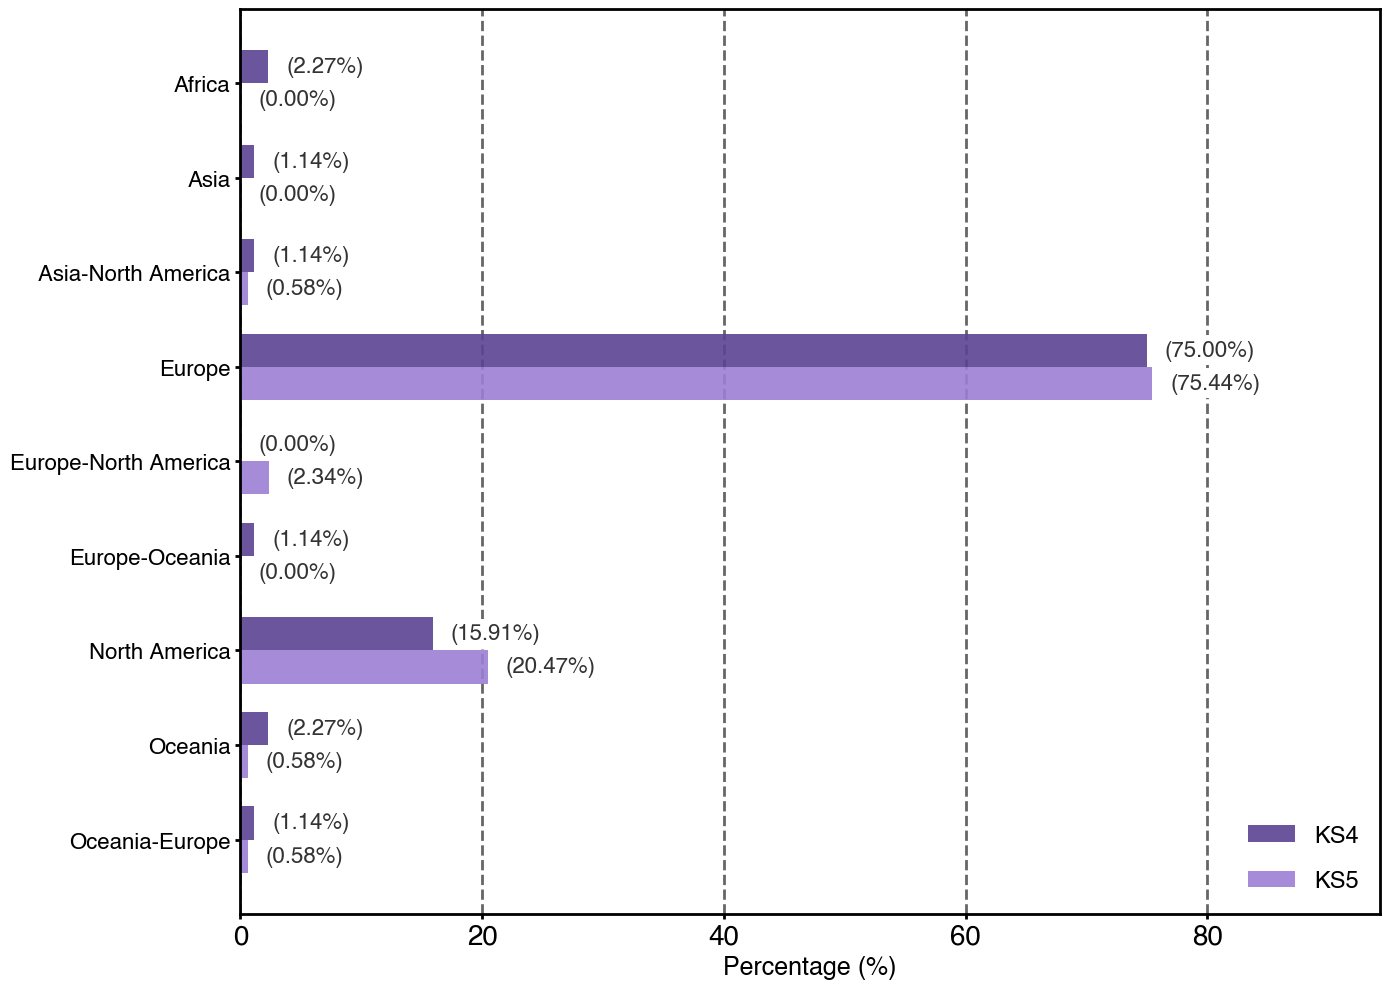

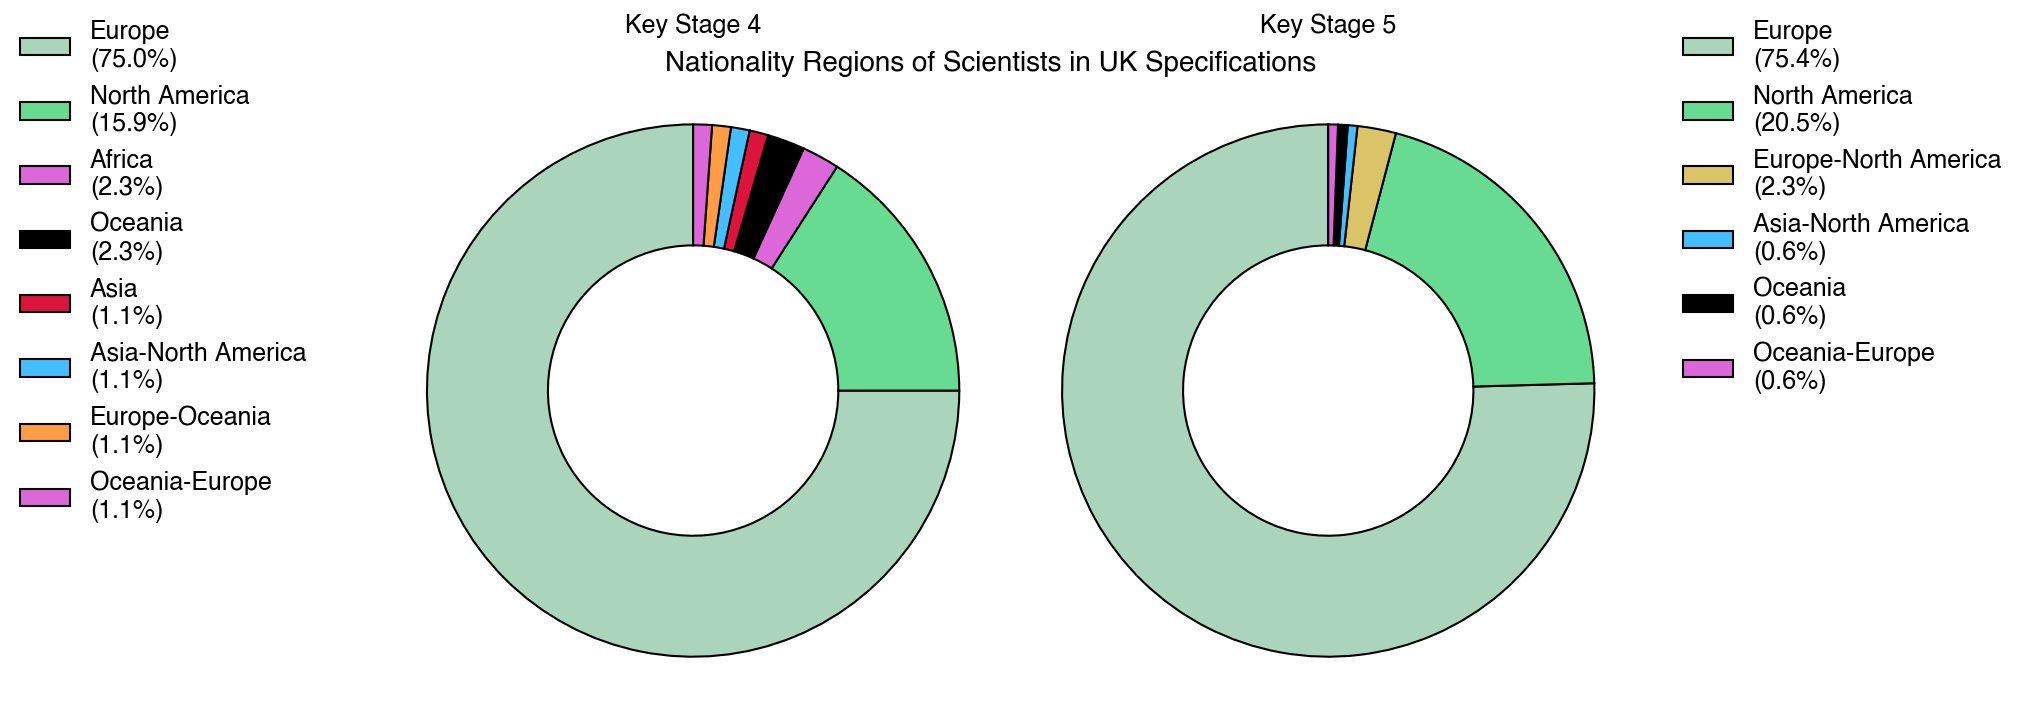

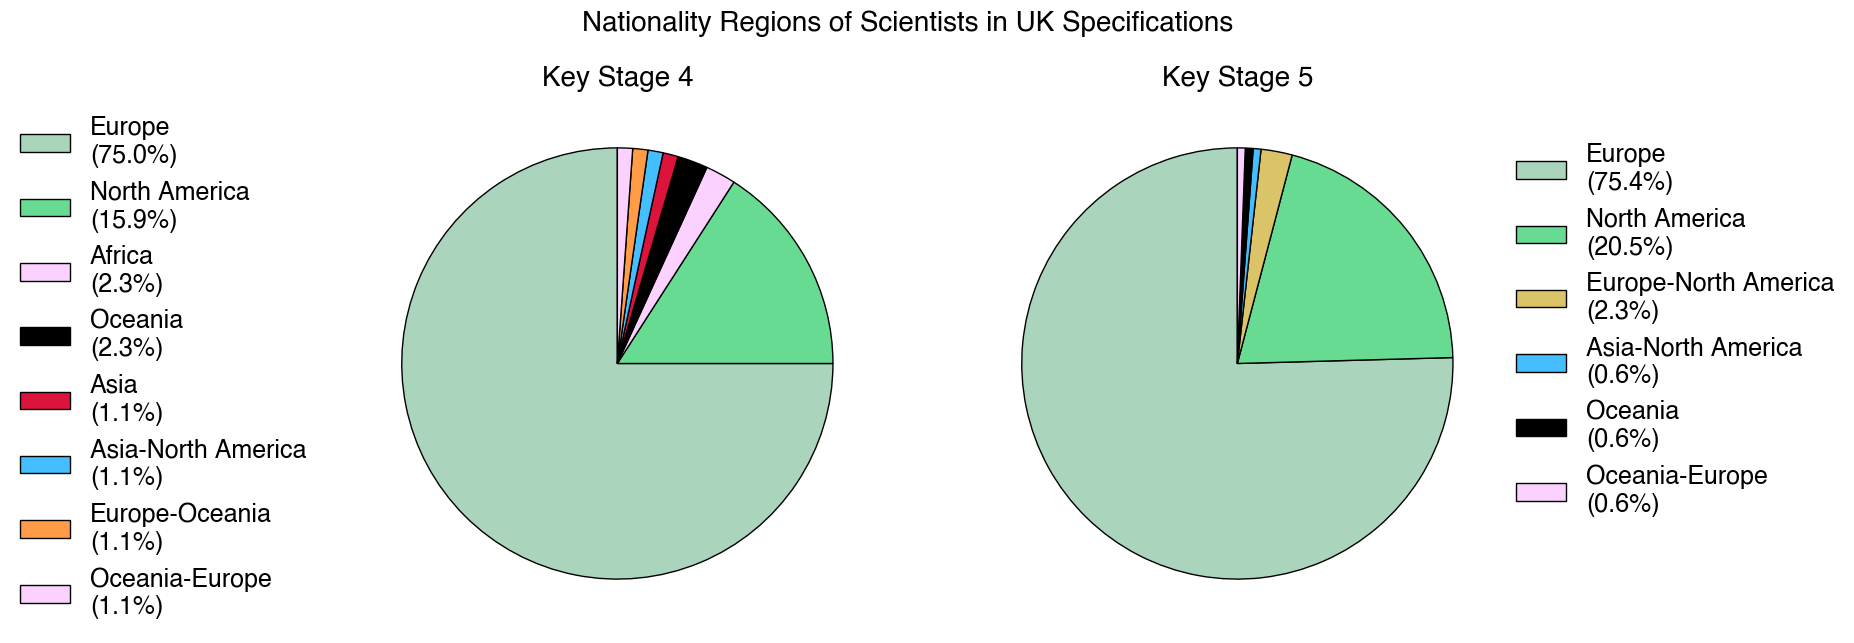

In [9]:
regions_A, vals_A, labels_A = ks5["regions"], ks5["vals"], ks5["labels"]
regions_G, vals_G, labels_G = ks4["regions"], ks4["vals"], ks4["labels"]
# Same grouped bar as Plot_Figures_UK.py (_run_script)
pf.plot_combined_grouped_bar(regions_A, vals_A, regions_G, vals_G)
pf.plot_combined_regions_donut(regions_G, vals_G, labels_G, regions_A, vals_A, labels_A)
pf.plot_combined_regions_solid(regions_G, vals_G, labels_G, regions_A, vals_A, labels_A)


# Distinct individual scientist names

Run the cell below after the KS5 and KS4 data cells (cells that set `ks5` and `ks4`).


In [10]:
print("=== A-Level / KS5 — distinct individual names ===")
print(f"Total: {len(ks5['scientists'])}\n")
for name in sorted(ks5["scientists"].keys()):
    print(name)

print("\n=== GCSE / KS4 — distinct individual names ===")
print(f"Total: {len(ks4['scientists'])}\n")
for name in sorted(ks4["scientists"].keys()):
    print(name)


=== A-Level / KS5 — distinct individual names ===
Total: 171

albert a. michelson
albert einstein
albert tullgren
alexander william williamson
alfred russel wallace
amedeo avogadro
andrew miall
andrija mohorovi?i?
archimedes of syracuse
arthur holly compton
ben goldacre
beno gutenberg
bernard sachs
bernhard tollens
bryan sykes
camillo golgi
charles darwin
charles friedel
charles lyell
charles spearman
charles vernon boys
charles-augustin de coulomb
christiaan huygens
christian bohr
christian doppler
christopher kelk ingold
clarence zener
clopton havers
daniel bernoulli
donald ransom whitney
dr. alois alzheimer
dr. james parkinson
edward hugh simpson
edward w. morley
edwin hall
edwin hubble
ejnar hertzsprung
ernest rutherford
ernst wilhelm büchner
erwin chargraff
filip hjulström
filippo pacini
francis crick
franklin stahl
franz melde
françois jacob
frederick grinnell
frederick lincoln
friedrich august kekulé
friedrich gustav jakob henle
friedrich hund
friedrich mohs
fritz haber
fritz lo